# Week 8 - Introduction to Deep Learning

## Day 1: From Machine Learning Models to Neural Networks


**Learning Goal:**

By the end of Day 1, students will understand:

- Why Deep Learning became necessary after classical Machine Learning.
- How Neural Networks are connected to previously learned models, especially Logistic Regression.
- The mathematical structure of an artificial neuron.
- The role of weights, bias, and activation functions.
- Why non-linearity is essential in Deep Learning.
- The limitation of single-layer perceptrons and the motivation for Multi-Layer Neural Networks.

---

# Session 1 (1.5 Hours)

# From Logistic Regression to Neural Networks

---

# 1. Learning Path: From AI to Deep Learning

Before introducing Neural Networks, students should understand where Deep Learning fits in the broader AI landscape.

```

Artificial Intelligence

```
    |
    |
```

Machine Learning

```
    |
    |
```

Deep Learning

```
    |
    |
```

Neural Networks

```

## Artificial Intelligence (AI)

Artificial Intelligence is the broad field of creating systems that can perform tasks requiring human intelligence.

Examples:

- Understanding language
- Recognizing images
- Making decisions
- Playing games

---

## Machine Learning (ML)

Machine Learning is a subset of AI where systems learn patterns from data instead of being explicitly programmed.

Traditional programming:

```

Rules + Data
|
|
Program
|
|
Output

```

Machine Learning:

```

Data + Expected Output
|
|
Learning Algorithm
|
|
Model

```

---

## Deep Learning (DL)

Deep Learning is a specialized branch of Machine Learning that uses multi-layer neural networks to automatically learn complex representations from data.

Examples:

- Image recognition
- Speech recognition
- Natural Language Processing
- Large Language Models

---

# 2. Why Do We Need Deep Learning?

You have already learned classical Machine Learning algorithms:

- Linear Regression
- Logistic Regression
- K-Nearest Neighbors
- Decision Trees
- K-Means Clustering

Now we ask:

> What are the limitations of classical ML models?

---

# Classical Models vs Neural Networks

| Model | Main Idea | Limitation |
|---|---|---|
| Linear Regression | Find the best line | Only learns linear relationships |
| Logistic Regression | Find a linear decision boundary | Cannot solve complex boundaries |
| KNN | Compare distances | Expensive for large datasets |
| Decision Tree | Learn decision rules | Can easily overfit |
| Neural Network | Learn complex transformations | Requires more data and computation |

---

# 3. The Main Idea Behind Neural Networks

The main idea:

> Instead of manually designing features, let the model learn useful representations automatically.

Example:

## Traditional Computer Vision

Human-designed features:

```

Image

↓

Edges

↓

Shapes

↓

Objects

↓

Classification

```

---

## Deep Learning Approach

```

Image

↓

Neural Network

↓

Learned Features

↓

Prediction

```

The network learns:

- Edges
- Shapes
- Patterns
- High-level concepts

automatically.

---

# 4. Relationship Between Logistic Regression and Neural Networks

Students already know Logistic Regression.

A Logistic Regression model:

$$
z = w^Tx+b
$$


Prediction:

$$
y=\sigma(z) = \frac{1}{1 + e^{-z}}
$$


where:

- $x$ = input features
- $w$ = weights
- $b$ = bias
- $\sigma$ = sigmoid activation function

---

<img src="img/lgr.jpg" width="500">

# Loss function
MSE loss function is convex for linear regression but non-convex for logistic regression

<img src="img/lgr_loss.png" width="500">


# Cross-Entropy Loss for Binary Logistic Regression

In **binary logistic regression**, the model predicts the probability that an input belongs to the positive class.

The predicted probability is given by the sigmoid function:

$$
\hat{y}
=
P(y=1\mid\mathbf{x})
=
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

where

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

---

## Cross-Entropy Loss for One Training Example

For a single training sample, the binary cross-entropy (log loss) is

$$
L(y,\hat{y})
=
-\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
$$

where

- $y \in \{0,1\}$ is the true label.
- $\hat{y}$ is the predicted probability of class 1.

---

## Cross-Entropy Loss for the Entire Dataset

For a dataset containing $N$ training samples,

$$
J(\mathbf{w},b)
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where

$$
\hat{y}_i
=
\sigma(\mathbf{w}^T\mathbf{x}_i+b)
$$

---

## Piecewise Interpretation

The loss can also be written as

$$
L(y,\hat{y})
= =
-\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right]
=
\begin{cases}
-\log(\hat{y}) & \text{if } y=1 \\
-\log(1-\hat{y}) & \text{if } y=0
\end{cases}
$$

This means:

- If the true label is **1**, the model is rewarded for predicting a probability close to **1**.
- If the true label is **0**, the model is rewarded for predicting a probability close to **0**.

---

## Example

Suppose the true label is

$$
y=1
$$

### Good Prediction

$$
\hat{y}=0.95
$$

$$
L
=
-\log(0.95)
=
0.051
$$

Very small loss.

---

### Poor Prediction

$$
\hat{y}=0.10
$$

$$
L
=
-\log(0.10)
=
2.303
$$

Large loss.

---

## Why Cross-Entropy?

Cross-entropy has several advantages over Mean Squared Error (MSE) for logistic regression:

- It is **convex** for standard logistic regression.
- It strongly penalizes confident incorrect predictions.
- It is derived from the **Maximum Likelihood Estimation (MLE)** of a Bernoulli distribution.
- It produces simpler gradients, leading to faster and more stable optimization.

---

## Gradient of the Loss

One of the main reasons cross-entropy is preferred is its remarkably simple gradient.

For one training example,

$$
\frac{\partial L}{\partial z}
=
\hat{y}-y
$$

where

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

Therefore,

$$
\frac{\partial J}{\partial \mathbf{w}}
=
\frac{1}{N}
X^T(\hat{\mathbf{y}}-\mathbf{y})
$$

and

$$
\frac{\partial J}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)
$$

These simple gradients are one reason why gradient descent converges efficiently for logistic regression.

---

## Summary

| Quantity | Formula |
|----------|---------|
| Sigmoid Function | $\displaystyle \hat{y}=\frac{1}{1+e^{-(\mathbf{w}^T\mathbf{x}+b)}}$ |
| Single-Sample Cross-Entropy | $\displaystyle L=-\left[y\log(\hat{y})+(1-y)\log(1-\hat{y})\right]$ |
| Dataset Cost Function | $\displaystyle J=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]$ |
| Gradient w.r.t. $z$ | $\displaystyle \frac{\partial L}{\partial z}=\hat{y}-y$ |
| Optimization Property | Convex for standard binary logistic regression |


# A Single Artificial Neuron

A neuron performs almost the same operation:

```

Input Features

x1 ---- w1
x2 ---- w2
x3 ---- w3

```
    |
    |
```

Weighted Sum

```
    |
    |
```

Activation Function

```
    |
    |
  Output
```

```

Mathematically:

$$
z=w_1x_1+w_2x_2+w_3x_3+b
$$


or:

$$
z=W^TX+b
$$


Output:

$$
a=f(z)
$$


---

# Key Insight

A single neuron is very similar to Logistic Regression.

Therefore:

> Logistic Regression can be considered as a very simple neural network with one layer.

---

# Logistic Regression vs. Single Artificial Neuron

| Feature | Logistic Regression | Single Artificial Neuron |
|---------|---------------------|--------------------------|
| **Purpose** | Statistical model for binary classification | Basic building block of a neural network |
| **Architecture** | Single linear model followed by a sigmoid function | One neuron with weighted inputs, bias, and an activation function |
| **Input** | Feature vector $\mathbf{x}$ | Feature vector $\mathbf{x}$ |
| **Linear Combination** | $z=\mathbf{w}^T\mathbf{x}+b$ | $z=\mathbf{w}^T\mathbf{x}+b$ |
| **Activation Function** | Sigmoid (fixed) | Sigmoid, ReLU, Tanh, Leaky ReLU, etc. |
| **Output** | Probability of the positive class | Score: activated output of the neuron |
| **Output Range** | $0$ to $1$ | Depends on activation function |

---


# 5. Artificial Neuron Components

| Component | Meaning |
|---|---|
| Input | Information coming from data |
| Weight | Importance of each input |
| Bias | Additional adjustable parameter |
| Weighted Sum | Combination of inputs |
| Activation Function | Introduces non-linearity |
| Output | Final prediction |

---

# 6. Understanding Weights and Bias

Suppose we want to predict whether a student passes an exam.

### Input Features

```
x₁ = Study Hours
x₂ = Attendance
x₃ = Previous Scores
```

Each feature contributes to the final prediction, but **not equally**. The model learns how important each feature is by assigning a **weight** to it.

For example:

```
Weight of Study Hours      (w₁) = 0.8
Weight of Attendance       (w₂) = 0.3
Weight of Previous Scores  (w₃) = 0.5
```

---

## What Is a Weight?

A **weight** represents the **importance** or **influence** of a feature on the prediction.

The larger the absolute value of a weight, the greater its influence on the model's output.

For example:

- **Study Hours (0.8)** has the largest weight, so it has the strongest effect on predicting whether a student passes.
- **Attendance (0.3)** has a smaller weight, so it contributes less to the prediction.
- **Previous Scores (0.5)** has a moderate influence.

### Positive and Negative Weights

A weight can be either positive or negative.

- **Positive weight:** Increasing the feature increases the predicted probability.
- **Negative weight:** Increasing the feature decreases the predicted probability.

For example:

| Feature | Weight | Interpretation |
|---------|-------:|---------------|
| Study Hours | +0.8 | More study hours increase the probability of passing. |
| Attendance | +0.3 | Better attendance slightly increases the probability of passing. |
| Number of Missed Assignments | -0.7 | Missing more assignments decreases the probability of passing. |

---

## The Weighted Sum

The model first computes a weighted sum of all features:

$$
z=w_1x_1+w_2x_2+w_3x_3+b
$$

or more generally,

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

Each feature is multiplied by its corresponding weight before being added together.

### Example

Suppose a student has:

```
Study Hours       = 8
Attendance        = 90
Previous Scores   = 75
```

and the learned parameters are

```
w₁ = 0.8
w₂ = 0.3
w₃ = 0.5
b  = -50
```

Then

$$
z=(0.8)(8)+(0.3)(90)+(0.5)(75)-50
$$

$$
z=6.4+27+37.5-50=20.9
$$

This value is then passed through the sigmoid function to obtain the predicted probability.

---

## What Is the Bias?

The **bias** is an additional parameter that allows the model to shift the decision boundary.

It is represented by

$$
b
$$

and is added to the weighted sum:

$$
z= <w,x> + b =  \mathbf{w}^T\mathbf{x}+b
$$

Without the bias, the model would always be forced to make predictions based only on the weighted inputs.

The bias provides extra flexibility by allowing the model to make reasonable predictions even when all feature values are zero.

---

## Intuition Behind the Bias

Imagine a teacher deciding whether a student passes.

The teacher first gives points based on:

- Study hours
- Attendance
- Previous scores

These are the **weighted contributions**.

However, the teacher may also have a **general policy** such as:

- "Students start with 5 bonus points."
- "Everyone starts with a penalty of 10 points."
- "Passing is intentionally made harder this semester."

This overall adjustment is analogous to the **bias**.

The bias shifts the prediction upward or downward independently of the input features.

---

## Why Is Bias Important?

Without a bias term,

$$
z=\mathbf{w}^T\mathbf{x}
$$

the decision boundary is constrained to pass through the origin.

With a bias,

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

the decision boundary can move freely, allowing the model to fit the data much better.

---

## Real-World Analogy

Imagine you are evaluating a job applicant.

Each criterion has a different importance:

| Criterion | Weight |
|-----------|--------|
| Years of Experience | High |
| Education | Medium |
| Certifications | Low |

The final score is computed by combining these weighted factors.

Now suppose the company has a hiring policy:

> "Every applicant starts with an extra 10 points because we urgently need employees."

Those extra 10 points correspond to the **bias**.

Thus,

- **Weights** determine **how much each feature matters**.
- **Bias** provides an overall adjustment independent of the features.

---

## Summary

| Parameter | Meaning | Intuition |
|-----------|---------|-----------|
| Weight ($w_i$) | Importance of a feature | Determines how strongly a feature affects the prediction. |
| Positive Weight | Increases prediction | Larger feature value makes the positive class more likely. |
| Negative Weight | Decreases prediction | Larger feature value makes the positive class less likely. |
| Bias ($b$) | Constant offset | Shifts the decision boundary or baseline prediction. |
| Weighted Sum | $\mathbf{w}^T\mathbf{x}+b$ | Combines all feature contributions before applying the activation function. |

> **Think of weights as the "importance" of each feature and the bias as the model's "starting point" before considering any feature values.**

# 7. From One Neuron to Neural Network

<img src="img/mlp.png" width="750">

<img src="img/mlp2.png" width="750">

$\hat{y} = w^Tx + b$

$$\bar{x} = [x_1, x_2, \cdots, x_m , 1]$$
$$\bar{w} = [w_1, x_2, \cdots, w_m , b]$$
$$\hat{y} = \bar{w}^T\bar{x}$$

A single neuron can only learn simple patterns.

A Neural Network combines many neurons.

Example:

```

Input Layer

```
  |
  |
```

Hidden Layer 1

```
  |
  |
```

Hidden Layer 2

```
  |
  |
```

Output Layer

```

Each layer learns increasingly complex patterns.

---

# 8. The Perceptron

The Perceptron was one of the earliest neural network models.

Introduced by:

**Frank Rosenblatt - 1958**

The Perceptron:

- Receives inputs
- Calculates weighted sum
- Applies activation
- Produces output


Structure:

```

x1 ----
x2 -----
x3 ------> Weighted Sum ---> Activation ---> Output

```

---

# 9. The Limitation of Single Perceptron

# Why Can a Single Perceptron Only Solve Linearly Separable Problems?

A **single perceptron** makes its decision using a **linear equation**. Therefore, it can only separate data that can be divided by a **single straight line** (in 2D), a **plane** (in 3D), or a **hyperplane** (in higher dimensions).

---

## 1. How Does a Perceptron Make a Decision?

A perceptron first computes a weighted sum of the input features:

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

where

- $\mathbf{x}$ = input features
- $\mathbf{w}$ = weights
- $b$ = bias

Then it applies an activation function.

For the original perceptron, the activation is the **step function**:

$$
\hat{y}=
\begin{cases}
1 & \text{if } z \ge 0\\
-1 & \text{if } z < 0
\end{cases}
$$

Thus, the decision depends entirely on whether

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

---

## 2. What Is the Decision Boundary?

The equation

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

defines the **decision boundary**.

Its shape depends on the number of features:

| Number of Features | Decision Boundary |
|--------------------|-------------------|
| 1 | A point |
| 2 | A straight line |
| 3 | A plane |
| $n$ | A hyperplane |

Since this boundary is always **linear**, the perceptron can only separate data with a linear boundary.

---

<img src="img/perceptron_db.png" width="750">

<img src="img/perceptron_db2.png" width="750">

## 3. What Does Linearly Separable Mean?

A dataset is **linearly separable** if one straight line (or hyperplane) can perfectly separate the two classes.

### Example: Linearly Separable

```
Class ○

○     ○

----------------------  Decision Boundary

      ●      ●

          Class ●
```

A single line separates the two classes.

The perceptron can learn this perfectly.

---

## 4. Example of a Non-Linearly Separable Problem

Consider the famous **XOR** dataset.

| x₁ | x₂ | Output |
|----|----|--------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Visualizing the data:

OR
```
        x₂

1      ●      ●

0      ○      ●

       0      1      x₁
```

AND
```
        x₂

1      ○      ●

0      ○      ○

       0      1      x₁
```





```
        x₂

1      ●      ○

0      ○      ●

       0      1      x₁
```

No single straight line can separate the circles from the dots.

No matter how the line is rotated or shifted, at least one point will always be misclassified.

Therefore, a single perceptron **cannot solve the XOR problem**.



$$xor(a,b) = (a*\bar{b} )+(\bar{a}* b)$$

---

## 5. Why Can't the Perceptron Learn XOR?

The perceptron can only adjust:

- the weights ($\mathbf{w}$)
- the bias ($b$)

These parameters only change the **position** and **orientation** of a linear decision boundary.

They **cannot create curves or multiple regions**.

The perceptron is limited to finding solutions of the form

$$
\mathbf{w}^T\mathbf{x}+b=0.
$$

Since XOR requires a nonlinear boundary, no choice of weights and bias can perfectly classify the data.

---

## 6. Intuitive Analogy

Imagine placing a ruler on a sheet of paper.

You are allowed to:

- move it,
- rotate it,
- tilt it.

But you **cannot bend it**.

If one straight ruler separates the two groups, the perceptron succeeds.

If the separator must be curved or broken into multiple segments, the perceptron fails.

---

## 7. How Do Neural Networks Solve This Problem?

A **multi-layer neural network** combines several neurons.

Each neuron learns a different linear boundary.

By combining many linear boundaries, the network creates a **nonlinear decision boundary**.

For example,

```
Single Perceptron

------------------------

Only one straight line


Multi-Layer Neural Network

  \        /
   \______/       Curved boundary
  /      \
```

This allows neural networks to solve problems such as

- XOR
- Image classification
- Speech recognition
- Natural language processing

---

## 8. Mathematical Perspective

A single perceptron computes

$$
\hat{y}=f(\mathbf{w}^T\mathbf{x}+b),
$$

where $f$ is the step function (or another activation function).

Since

$$
\mathbf{w}^T\mathbf{x}+b
$$

is a **linear function**, the decision boundary is always linear.

Changing the weights changes only:

- the slope,
- the orientation,
- the position.

It **never changes the boundary into a curve**.

---

## Summary

| Property | Single Perceptron |
|----------|-------------------|
| Decision Boundary | Linear |
| Can Separate Linear Data | ✅ Yes |
| Can Separate XOR | ❌ No |
| Can Learn Curved Boundaries | ❌ No |
| Learns Weights and Bias | ✅ Yes |
| Solves Nonlinear Problems | ❌ No |
| Requires Hidden Layers for Nonlinear Problems | ✅ Yes |

---

## Key Takeaway

A **single perceptron** can only solve **linearly separable problems** because it always computes a **linear decision boundary**:

$$
\mathbf{w}^T\mathbf{x}+b=0.
$$

---



# Session 1 Summary

At the end of Session 1, students should understand:

- Deep Learning is a branch of Machine Learning.
- Neural Networks are built from artificial neurons.
- A neuron is mathematically similar to Logistic Regression.
- Weights and bias are learned parameters.
- Multiple neurons create layers.
- Multiple layers allow learning complex patterns.
- Single perceptrons cannot solve non-linear problems such as XOR.

---

<br>

# Session 2 (1.5 Hours)

# Activation Functions and Learning Non-Linear Patterns

---

# 1. Why Do We Need Activation Functions?

A neural network contains many layers.

A simple layer:

$$
z=Wx+b
$$


Assume two consecutive linear layers:

$$
z_1=W_1X+b_1
$$


Second layer:

$$
z_2=W_2z_1+b_2
$$


Replacing:

$$
z_2=W_2(W_1X+b_1)+b_2
=W_2W_1X + (W_2b_1+b_2)
$$


After simplification:

$$
z_2=WX+b
$$


Meaning:

> Stacking multiple linear layers without activation functions is still only one linear model.

---

# Important Conclusion

Activation functions allow neural networks to learn:

- Curves
- Complex boundaries
- Non-linear relationships

---

# 2. What is Non-Linearity?

A linear relationship:

```

y = ax + b

```

> creates a straight line.


> A non-linear relationship cannot be represented by a simple line.

---

# 3. Common Activation Functions

---

# Sigmoid Function

Formula:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$


Output range:

```

0 to 1

```

Graph behavior:

```

0 -------- 1

```

---

## Usage

Mostly used in:

- Binary Classification output layers


Example:

```

Spam probability = 0.92

```

---

## Problems

### Vanishing Gradient

For very large or small values:

the gradient becomes very small.

Consequences:

- Slow learning
- Difficulty training deep networks

---

# Tanh Function

Formula:

$$
tanh(x)
$$


Output range:

```

-1 to 1

```

Advantages:

- Zero-centered output

Disadvantage:

- Still suffers from vanishing gradient

---

# ReLU Function

Rectified Linear Unit:

$$
f(x)=max(0,x)
$$


Behavior:

```

Negative values → 0

Positive values → unchanged

```

---

## Advantages

- Simple computation
- Faster training
- Works well in deep networks

---

## Problem

Dead Neurons:

If a neuron always outputs zero, it may stop learning.

---

# GELU Function

Gaussian Error Linear Unit

Commonly used in:

- Transformers
- BERT
- GPT-based models

Modern Deep Learning systems often use GELU instead of ReLU.

---

# 4. Activation Function Selection

| Problem Type | Output Activation |
|---|---|
| Binary Classification | Sigmoid |
| Multi-Class Classification | Softmax |
| Regression | Linear |

---

# 5. Building a Complete Neural Network


## I. Problem Definition

### Goal

Classify flowers into two categories using a neural network.

### Dataset

We use the **Iris dataset**.

The input contains **4 features**:

```
x₁ = Sepal Length
x₂ = Sepal Width
x₃ = Petal Length
x₄ = Petal Width
```

The output is a binary class:

```
Class 0 → Setosa
Class 1 → Versicolor
```

---

## II. Neural Network Architecture

The network structure:

```
                 Input Layer

                 4 neurons
                     |
                     |
              Hidden Layer

                 8 neurons
                   ReLU
                     |
                     |
              Output Layer

                 1 neuron
                Sigmoid
                     |
                     |
               Prediction
```

Mathematically:

$$
x \rightarrow ReLU(W_1x+b_1)
\rightarrow
\sigma(W_2a+b_2)
\rightarrow
\hat{y}
$$

---

# Multi-Layer Perceptron (MLP) for Binary Flower Classification Using PyTorch

## I. Problem Definition

### Goal

Build a neural network to classify flowers into two categories.

We use the **Iris dataset** and convert it into a binary classification problem.

### Input Features

The model receives 4 input features:

```
x₁ = Sepal Length
x₂ = Sepal Width
x₃ = Petal Length
x₄ = Petal Width
```

### Output

Binary class prediction:

```
Class 0 → Setosa
Class 1 → Versicolor
```

---

# II. Neural Network Architecture

The MLP architecture:

```
                 Input Layer

                 4 neurons
                     |
                     |
              Hidden Layer

                 8 neurons
                   ReLU
                     |
                     |
              Output Layer

                 1 neuron
                Sigmoid
                     |
                     |
               Prediction
```

Mathematically:

$$
x
\rightarrow
ReLU(W_1x+b_1)
\rightarrow
\sigma(W_2a+b_2)
\rightarrow
\hat{y}
$$

---

# III. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

---

# IV. Load Iris Dataset

The Iris dataset contains:

- 150 samples
- 4 features
- 3 classes

For binary classification, we select only two classes.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


# V. Convert Dataset to Binary Classification

Keep only:

```
Class 0 → Setosa
Class 1 → Versicolor
```

In [3]:
mask = y < 2

X = X[mask]
y = y[mask]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (100, 4)
Target shape: (100,)


---

# VI. Split Training and Testing Data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

---

# VII. Feature Scaling

Neural networks train better when input features have similar ranges.

We standardize each feature:

$$
x'=\frac{x-\mu}{\sigma}
$$

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

---

# VIII. Convert Data to PyTorch Tensors

PyTorch models operate on tensors.

In [6]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)


X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).reshape(-1, 1)

---

# IX. Create DataLoader

The DataLoader provides:

- mini-batches
- data shuffling
- efficient iteration

In [7]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

---

# X. Define the MLP Model

The network:

```
Input Layer
    |
    | 4 features
    |
Hidden Layer
    |
    | 8 neurons
    | ReLU
    |
Output Layer
    |
    | 1 neuron
    | Sigmoid
    |
Prediction
```

PyTorch implementation:

In [8]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(4, 8),

            nn.ReLU(),

            nn.Linear(8, 1),

            nn.Sigmoid()
        )


    def forward(self, x):

        return self.network(x)

---

# XI. Create Model Instance

In [9]:
model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


---

# XII. Define Loss Function and Optimizer

For binary classification:

- Loss function: Binary Cross Entropy
- Optimizer: Adam

In [10]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

---

# XIII. Train the Neural Network

During training, the model learns:

- weights $$W$$
- biases $$b$$

using:

1. Forward propagation
2. Loss calculation
3. Backpropagation
4. Weight update

In [11]:
epochs = 100

loss_history = []


for epoch in range(epochs):

    total_loss = 0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()


    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)


    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{epochs}, "
            f"Loss: {avg_loss:.4f}"
        )

Epoch 10/100, Loss: 0.3954
Epoch 20/100, Loss: 0.2035
Epoch 30/100, Loss: 0.1045
Epoch 40/100, Loss: 0.0595
Epoch 50/100, Loss: 0.0373
Epoch 60/100, Loss: 0.0253
Epoch 70/100, Loss: 0.0181
Epoch 80/100, Loss: 0.0136
Epoch 90/100, Loss: 0.0106
Epoch 100/100, Loss: 0.0084


---

# XIV. Evaluate the Model

Set the model to evaluation mode:

In [12]:
model.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Disable gradient calculation:

In [13]:
with torch.no_grad():

    outputs = model(
        X_test_tensor
    )

    predictions = (
        outputs >= 0.5
    ).float()

Calculate accuracy:


In [14]:
accuracy = (
    predictions == y_test_tensor
).float().mean()


print(
    "Test Accuracy:",
    accuracy.item()
)

Test Accuracy: 1.0



---

# XV. Make Predictions

The output neuron produces a probability:


In [15]:
model.eval()

with torch.no_grad():

    probabilities = model(
        X_test_tensor
    )


print(probabilities[:5])

tensor([[0.9984],
        [0.9958],
        [0.9951],
        [0.0073],
        [0.0040]])


Interpretation:

```
0.9979 → 99.79% probability of Class 1

0.006 → 0.6% probability of Class 1
```

---

# XVI. Convert Probability to Class

Decision rule:

$$
\hat{y}
=
\begin{cases}
1 & probability \ge 0.5\\
0 & probability < 0.5
\end{cases}
$$

Python:

In [16]:
classes = (
    probabilities >= 0.5
).int()

print(classes[:5])

tensor([[1],
        [1],
        [1],
        [0],
        [0]], dtype=torch.int32)



---

# XVII. Visualize Training Loss


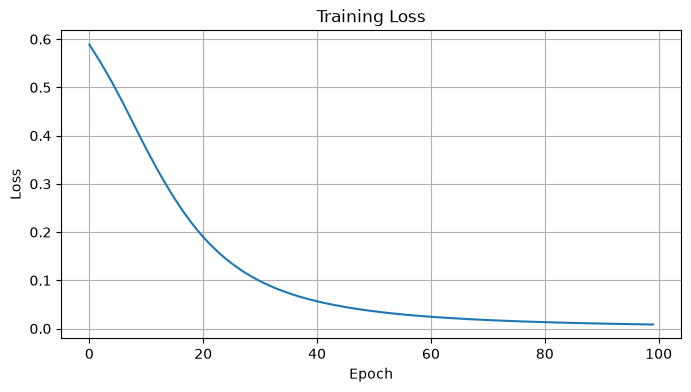

In [17]:
plt.figure(figsize=(8,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training Loss"
)

plt.grid()

plt.show()


---

# XVIII. Mathematical Explanation

## Hidden Layer

The first layer performs:

$$
z_1=W_1x+b_1
$$

Then applies ReLU:

$$
a_1=ReLU(z_1)
$$

where:

$$
ReLU(x)=max(0,x)
$$

---

## Output Layer

The output layer computes:

$$
z_2=W_2a_1+b_2
$$

Then applies sigmoid:

$$
\hat{y}
=
\sigma(z_2)
$$

where:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The final output is the probability of belonging to class 1.

---

# XIX. Relationship with Logistic Regression

Logistic Regression:

$$
\hat{y}
=
\sigma(Wx+b)
$$

MLP:

$$
\hat{y}
=
\sigma
(
W_2ReLU(W_1x+b_1)+b_2
)
$$

The hidden layer creates new learned features:

$$
x
\rightarrow
\text{learned representations}
\rightarrow
\text{prediction}
$$

Therefore:

$$
\boxed{
MLP
=
Logistic\ Regression
+
Hidden\ Layer
+
Nonlinear\ Feature\ Learning
}
$$

---

# XX. Key Concepts Learned

| Concept | Explanation |
|---|---|
| Tensor | PyTorch data structure used for computation |
| Linear Layer | Computes weighted sum $$Wx+b$$ |
| Activation Function | Adds nonlinearity |
| ReLU | Hidden layer activation |
| Sigmoid | Converts output to probability |
| Loss Function | Measures prediction error |
| Backpropagation | Computes gradients |
| Optimizer | Updates weights and biases |
| MLP | Neural network with one or more hidden layers |

# 6. Deep Learning Vocabulary

## Layer

A group of neurons.

---

## Hidden Layer

A layer between input and output.

---

## Deep Network

A network with multiple hidden layers.

Example:

```

Input

↓

Hidden 1

↓

Hidden 2

↓

Hidden 3

↓

Output

```

---

# 7. Neural Network Design Decisions

When creating a neural network, we choose:

## Number of Layers

More layers:

- More learning capacity
- More risk of overfitting

---

## Number of Neurons

More neurons:

- Can learn more patterns
- Requires more data

---

## Activation Function

Determines:

- Type of learned relationships

---

# Session 2 Summary

Students should understand:

- Why activation functions are necessary.
- Difference between linear and non-linear models.
- The role of Sigmoid, Tanh, ReLU, and GELU.
- How activation functions enable Deep Learning.
- Basic architecture of a neural network.
- How Neural Networks extend Logistic Regression into deeper models.

---

# Day 1 Final Exercise

## Conceptual Questions

1. Why is Logistic Regression considered similar to a single neuron?
2. Why cannot a single perceptron solve XOR?
3. Why do neural networks need activation functions?
4. What happens if we remove activation functions from all layers?
5. Which activation function would you choose for:
   - Binary classification?
   - Multi-class classification?
   - Regression?


## Preparation for Day 2

Next session:

**How Neural Networks Learn**

Topics:

- Loss Functions
- Gradient Descent
- Backpropagation
- Optimization
- First Neural Network Implementation with PyTorch

# Further Reading: Why is Mean Squared Error (MSE) Non-Convex for Logistic Regression but Convex for Linear Regression?

The key reason is **not the Mean Squared Error (MSE) itself**, but **the function it is composed with**.

Let's compare the two models.

| Linear Regression | Logistic Regression |
|-------------------|---------------------|
| Prediction: $\hat{y} = \mathbf{w}^T\mathbf{x} + b$ | Prediction: $\hat{y} = \sigma(\mathbf{w}^T\mathbf{x} + b)$ |
| Linear model | Nonlinear sigmoid model |
| MSE is convex | MSE is generally non-convex |

---

## 1. Linear Regression: Convex

The prediction is simply

$$
\hat{y} = \mathbf{w}^T\mathbf{x} + b
$$

The Mean Squared Error is

$$
J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

Substitute the prediction:

$$
J(\mathbf{w}) =
\frac{1}{N}
\sum_{i=1}^{N}
\left(y_i-(\mathbf{w}^T\mathbf{x}_i+b)\right)^2
$$

Notice what happens:

- $\mathbf{w}^T\mathbf{x}+b$ is **linear** in the parameters.
- Squaring a linear function produces a **quadratic** function.
- A quadratic function with a positive coefficient matrix is **convex**.

In matrix notation,

$$
J(\mathbf{w})
=
\frac{1}{N}
\|X\mathbf{w}-\mathbf{y}\|^2
$$

The Hessian matrix is

$$
H=\frac{2}{N}X^TX
$$

Since

$$
X^TX
$$

is always **positive semidefinite**, the Hessian is always positive semidefinite.

Therefore, the cost function is convex.

### Visualization

```
Cost
 ^
 |        •
 |      •
 |    •
 |  •
 +-------------------->
          w
```

The optimization landscape is a single bowl, so gradient descent converges to the global minimum.

---

## 2. Logistic Regression: MSE Becomes Non-Convex

The prediction is

$$
\hat{y}
=
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

where

$$
z=\mathbf{w}^T\mathbf{x}+b
$$

The MSE becomes

$$
J(\mathbf{w})
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i-\sigma(\mathbf{w}^T\mathbf{x}_i+b)
\right)^2
$$

Now the parameters appear **inside the sigmoid function**.

Instead of minimizing

> Quadratic of a **linear** function

we are minimizing

> Quadratic of a **nonlinear** function

This composition destroys convexity.

---

## 3. Why Does the Sigmoid Break Convexity?

The sigmoid function is

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Its first derivative is

$$
\sigma'(z)
=
\sigma(z)(1-\sigma(z))
$$

Its second derivative is

$$
\sigma''(z)
=
\sigma(z)(1-\sigma(z))
(1-2\sigma(z))
$$

Observe:

- For $z<0$, $\sigma''(z)>0$
- For $z>0$, $\sigma''(z)<0$

Therefore, the sigmoid function is

- **Convex** on one side
- **Concave** on the other side

Because of this changing curvature,

$$
(y-\sigma(z))^2
$$

also changes curvature.

Consequently, the Hessian of the MSE loss is **not always positive semidefinite**.

Therefore, the optimization problem is **non-convex**.

### Visualization

```
Cost
 ^
 |      __
 |   __/  \__
 |__/        \__
 +-------------------->
          w
```

Unlike linear regression, the cost surface may contain flat regions, saddle points, or local minima, making optimization more challenging.

---

## 4. Why Does Logistic Regression Use Cross-Entropy Instead?

Instead of MSE, logistic regression uses the **Cross-Entropy (Log Loss)**

$$
J(\mathbf{w})
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where

$$
\hat{y}
=
\sigma(\mathbf{w}^T\mathbf{x}+b)
$$

Although the sigmoid function is nonlinear, combining it with the logarithm causes the derivatives to simplify nicely.

The Hessian becomes

$$
H=X^TWX
$$

where

$$
W=
\operatorname{diag}
\left(
\hat{y}_i(1-\hat{y}_i)
\right)
$$

Since

$$
\hat{y}_i(1-\hat{y}_i)\ge0
$$

the matrix $W$ is positive semidefinite.

Therefore,

$$
X^TWX
$$

is also positive semidefinite.

As a result, the cross-entropy loss is **convex** for standard logistic regression.

---

## Summary

| Model | Prediction | Loss Function | Convex? |
|--------|------------|---------------|----------|
| Linear Regression | $\mathbf{w}^T\mathbf{x}+b$ | Mean Squared Error (MSE) | ✅ Yes |
| Logistic Regression | $\sigma(\mathbf{w}^T\mathbf{x}+b)$ | Mean Squared Error (MSE) | ❌ No |
| Logistic Regression | $\sigma(\mathbf{w}^T\mathbf{x}+b)$ | Cross-Entropy (Log Loss) | ✅ Yes |

---

## Key Takeaway

- **Linear Regression + MSE** is convex because the prediction is **linear** in the parameters, resulting in a quadratic optimization problem.
- **Logistic Regression + MSE** is non-convex because the prediction passes through the **nonlinear sigmoid function**, introducing changing curvature into the loss surface.
- **Logistic Regression + Cross-Entropy** is convex because the logarithm and sigmoid complement each other mathematically, producing a positive semidefinite Hessian and a single global optimum.